# Resume Embeddings and Job Matching

## Objective

This notebook generates semantic embeddings for resumes and job descriptions using transformer models.

The embeddings are used to:

- Understand resume meaning
- Understand job description meaning
- Compute similarity scores
- Rank candidates automatically

Model Used:
- Sentence Transformers
- all-MiniLM-L6-v2

In [1]:
import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

c:\Users\KIIT\OneDrive\Desktop\TalentMatch_AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv(
    "../data/processed/nlp_processed_resumes.csv"
)

print(df.shape)

(2458, 7)


# Loading Transformer Model

In [3]:
model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4581.17it/s]


In [4]:
sample_df = df.head(500).copy()

In [5]:
resume_embeddings = model.encode(
    sample_df["Cleaned_Resume"].tolist(),
    show_progress_bar=True
)

Batches: 100%|██████████| 16/16 [00:10<00:00,  1.52it/s]


In [6]:
print(resume_embeddings.shape)

(500, 384)


# Sample Job Description

In [7]:
job_description = """
Looking for a Python Developer with experience in:

Python
Machine Learning
Data Analysis
SQL
NLP
Deep Learning
Scikit-learn
Pandas
NumPy

Strong problem-solving skills required.
"""

In [8]:
jd_embedding = model.encode(
    [job_description]
)

In [9]:
similarity_scores = cosine_similarity(
    jd_embedding,
    resume_embeddings
)

In [10]:
sample_df["Match_Score"] = similarity_scores[0]

In [11]:
ranked_candidates = sample_df.sort_values(
    by="Match_Score",
    ascending=False
)

In [12]:
ranked_candidates[
    [
        "ID",
        "Category",
        "Match_Score"
    ]
].head(10)

,ID,Category,Match_Score
307,16186411,INFORMATION-TECHNOLOGY,0.280594
127,12415691,DESIGNER,0.274497
309,26746496,INFORMATION-TECHNOLOGY,0.274192
115,11919526,DESIGNER,0.272641
289,20674668,INFORMATION-TECHNOLOGY,0.262312
256,90867631,INFORMATION-TECHNOLOGY,0.258771
279,37242217,INFORMATION-TECHNOLOGY,0.255756
259,24083609,INFORMATION-TECHNOLOGY,0.252311
295,83816738,INFORMATION-TECHNOLOGY,0.251968
161,30968749,DESIGNER,0.250164


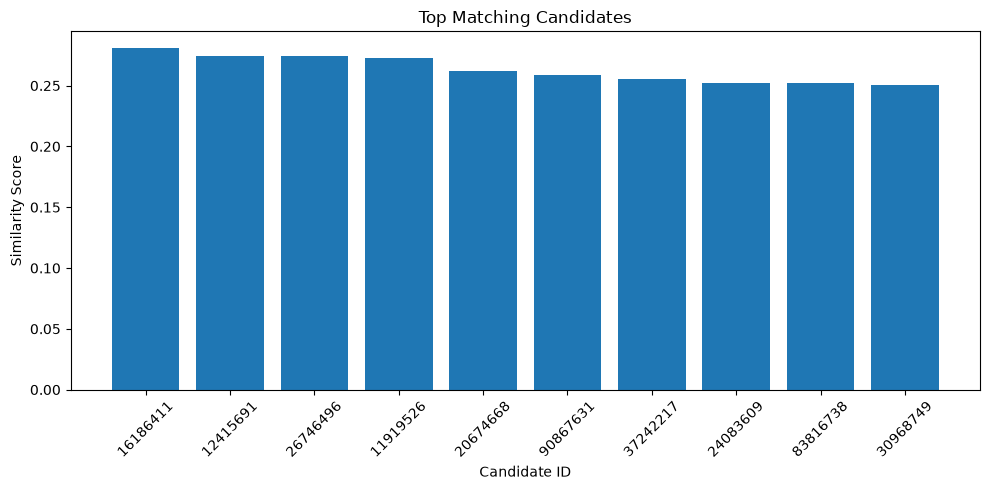

In [13]:
import matplotlib.pyplot as plt

top10 = ranked_candidates.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["ID"].astype(str),
    top10["Match_Score"]
)

plt.xticks(rotation=45)

plt.title("Top Matching Candidates")

plt.xlabel("Candidate ID")

plt.ylabel("Similarity Score")

plt.tight_layout()

plt.show()

In [14]:
ranked_candidates.to_csv(
    "../data/processed/ranked_candidates.csv",
    index=False
)